In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

import os

path = '/kaggle/input/datasets/yamqwe/chicken-weight-vs-different-chicken-feeds'
print(os.listdir(path))

['chickweight.csv']


In [2]:
df_raw = pd.read_csv('/kaggle/input/datasets/yamqwe/chicken-weight-vs-different-chicken-feeds/chickweight.csv')

In [3]:
print("✅ Dataset asli berhasil diload!")
print(f"   Shape : {df_raw.shape}")
print(f"\n--- 5 Baris Pertama ---")
print(df_raw.head(10))
print(f"\n--- Info Kolom ---")
print(df_raw.info())
print(f"\n--- Statistik Dasar ---")
print(df_raw.describe().round(2))
print(f"\n--- Nilai unik kolom 'Diet' ---")
print(df_raw['Diet'].value_counts())
print(f"\n--- Nilai unik kolom 'Time' (hari pengukuran) ---")
print(sorted(df_raw['Time'].unique()))

✅ Dataset asli berhasil diload!
   Shape : (578, 4)

--- 5 Baris Pertama ---
   weight  Time  Chick  Diet
0      42     0      1     1
1      51     2      1     1
2      59     4      1     1
3      64     6      1     1
4      76     8      1     1
5      93    10      1     1
6     106    12      1     1
7     125    14      1     1
8     149    16      1     1
9     171    18      1     1

--- Info Kolom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   weight  578 non-null    int64
 1   Time    578 non-null    int64
 2   Chick   578 non-null    int64
 3   Diet    578 non-null    int64
dtypes: int64(4)
memory usage: 18.2 KB
None

--- Statistik Dasar ---
       weight    Time   Chick    Diet
count  578.00  578.00  578.00  578.00
mean   121.82   10.72   25.75    2.24
std     71.07    6.76   14.57    1.16
min     35.00    0.00    1.00    1.00
25%     63.

In [4]:
# --- Rename kolom agar lebih deskriptif ---
df = df_raw.rename(columns={
    'weight' : 'bobot_badan_g',
    'Time'   : 'umur_hari',
    'Chick'  : 'chick_id',
    'Diet'   : 'jenis_diet'
})

# Hapus baris umur 0 (bobot lahir, belum relevan untuk FCR)
df = df[df['umur_hari'] > 0].copy()
df = df.reset_index(drop=True)

print(f"✅ Dataset setelah filter umur > 0: {df.shape}")

✅ Dataset setelah filter umur > 0: (528, 4)


In [5]:
n = len(df)

# --- 1. Suhu Kandang (°C) ---
# Ideal 26–30°C. Makin tua ayam, suhu target makin turun.
# Variasi antar kandang ditambahkan via noise
suhu_base = 32 - (0.25 * df['umur_hari'])          # turun seiring umur
df['suhu_kandang_C'] = np.round(
    suhu_base + np.random.normal(0, 1.5, n), 1
)
df['suhu_kandang_C'] = df['suhu_kandang_C'].clip(22, 36)

# --- 2. Kelembaban (%) ---
# Ideal 60–70%. Berkorelasi positif lemah dengan suhu
df['kelembaban_pct'] = np.round(
    65 + (df['suhu_kandang_C'] - 28) * 0.8
    + np.random.normal(0, 5, n), 1
)
df['kelembaban_pct'] = df['kelembaban_pct'].clip(40, 90)

# --- 3. Kepadatan Kandang (ekor/m²) ---
# Standar broiler: 10–12 ekor/m². Beberapa kandang overpadding.
df['kepadatan_m2'] = np.round(
    np.random.uniform(8, 14, n), 1
)

# --- 4. Mortalitas Kumulatif (%) ---
# Naik seiring umur, lebih tinggi jika suhu > 32°C atau padat > 13
stress_suhu  = np.where(df['suhu_kandang_C'] > 32, 1.2, 0)
stress_padat = np.where(df['kepadatan_m2'] > 13, 0.8, 0)
df['mortalitas_pct'] = np.round(
    np.random.exponential(1.2, n)
    + (df['umur_hari'] * 0.03)
    + stress_suhu + stress_padat, 2
)
df['mortalitas_pct'] = df['mortalitas_pct'].clip(0, 10)

# --- 5. Konsumsi Pakan Kumulatif (g/ekor) ---
# Diturunkan dari bobot badan + pengaruh stres lingkungan
# FCR nyata = konsumsi / bobot, jadi konsumsi harus realistis
pengaruh_suhu_pakan  = np.where(df['suhu_kandang_C'] > 30, -0.07, 0)
pengaruh_padat_pakan = np.where(df['kepadatan_m2'] > 12, -0.04, 0)

df['konsumsi_pakan_g'] = np.round(
    df['bobot_badan_g'] * 1.72
    * (1 + pengaruh_suhu_pakan + pengaruh_padat_pakan)
    * np.random.normal(1, 0.04, n), 1
)
df['konsumsi_pakan_g'] = df['konsumsi_pakan_g'].clip(10, None)


In [6]:
fcr_raw = df['konsumsi_pakan_g'] / df['bobot_badan_g']

# Tambah efek stres dan umur terhadap FCR
efek_umur    = 0.007 * (df['umur_hari'] - 14)      # FCR naik pelan seiring umur
efek_panas   = np.where(df['suhu_kandang_C'] > 32, 0.10, 0)
efek_padat   = np.where(df['kepadatan_m2'] > 13,   0.08, 0)

df['fcr'] = np.round(
    fcr_raw + efek_umur + efek_panas + efek_padat
    + np.random.normal(0, 0.03, n), 3
)
df['fcr'] = df['fcr'].clip(1.35, 2.10)


In [7]:
df = df[[
    'chick_id', 'umur_hari', 'jenis_diet',
    'bobot_badan_g', 'konsumsi_pakan_g',
    'suhu_kandang_C', 'kelembaban_pct',
    'kepadatan_m2', 'mortalitas_pct',
    'fcr'   # <-- TARGET
]]

print(f"\n✅ Feature engineering selesai!")
print(f"   Shape final : {df.shape}")
print(f"\n--- 5 Baris Pertama ---")
print(df.head())
print(f"\n--- Statistik Deskriptif ---")
print(df.describe().round(3))
print(f"\n--- Cek Missing Value ---")
print(df.isnull().sum())
print(f"\n--- Distribusi FCR (Target) ---")
print(f"   Min  : {df['fcr'].min()}")
print(f"   Max  : {df['fcr'].max()}")
print(f"   Mean : {df['fcr'].mean():.3f}")
print(f"   Std  : {df['fcr'].std():.3f}")


✅ Feature engineering selesai!
   Shape final : (528, 10)

--- 5 Baris Pertama ---
   chick_id  umur_hari  jenis_diet  bobot_badan_g  konsumsi_pakan_g  \
0         1          2           1             51              80.2   
1         1          4           1             59              93.1   
2         1          6           1             64             102.6   
3         1          8           1             76             123.4   
4         1         10           1             93             159.3   

   suhu_kandang_C  kelembaban_pct  kepadatan_m2  mortalitas_pct    fcr  
0            32.2            69.7          13.8            2.59  1.702  
1            30.8            62.7           9.1            1.96  1.498  
2            31.5            71.0          13.1            1.95  1.644  
3            32.3            60.1          11.0            1.45  1.651  
4            29.1            65.5           9.5            2.02  1.684  

--- Statistik Deskriptif ---
       chick_id  umur

  EXPLORATORY DATA ANALYSIS — FCR PREDICTION


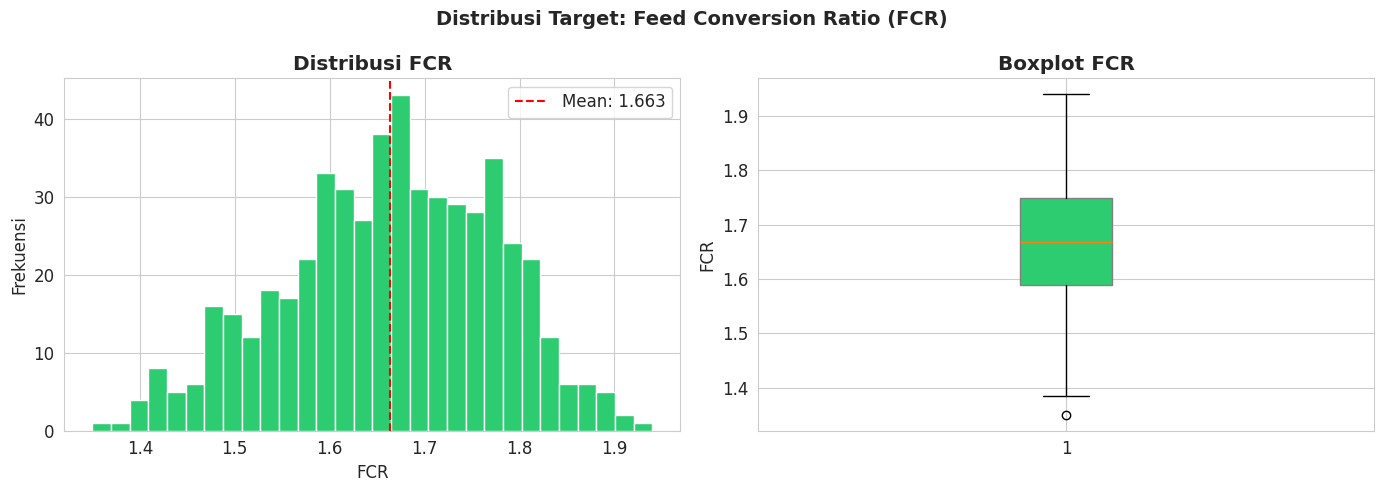

✅ Plot 1: Distribusi FCR selesai


In [8]:
print("=" * 55)
print("  EXPLORATORY DATA ANALYSIS — FCR PREDICTION")
print("=" * 55)

# ============================================================
# 3.1 DISTRIBUSI FCR (TARGET)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['fcr'], bins=30, color='#2ecc71', edgecolor='white')
axes[0].set_title('Distribusi FCR', fontweight='bold')
axes[0].set_xlabel('FCR')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['fcr'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['fcr'].mean():.3f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['fcr'], patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', color='gray'))
axes[1].set_title('Boxplot FCR', fontweight='bold')
axes[1].set_ylabel('FCR')

plt.suptitle('Distribusi Target: Feed Conversion Ratio (FCR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fcr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1: Distribusi FCR selesai")


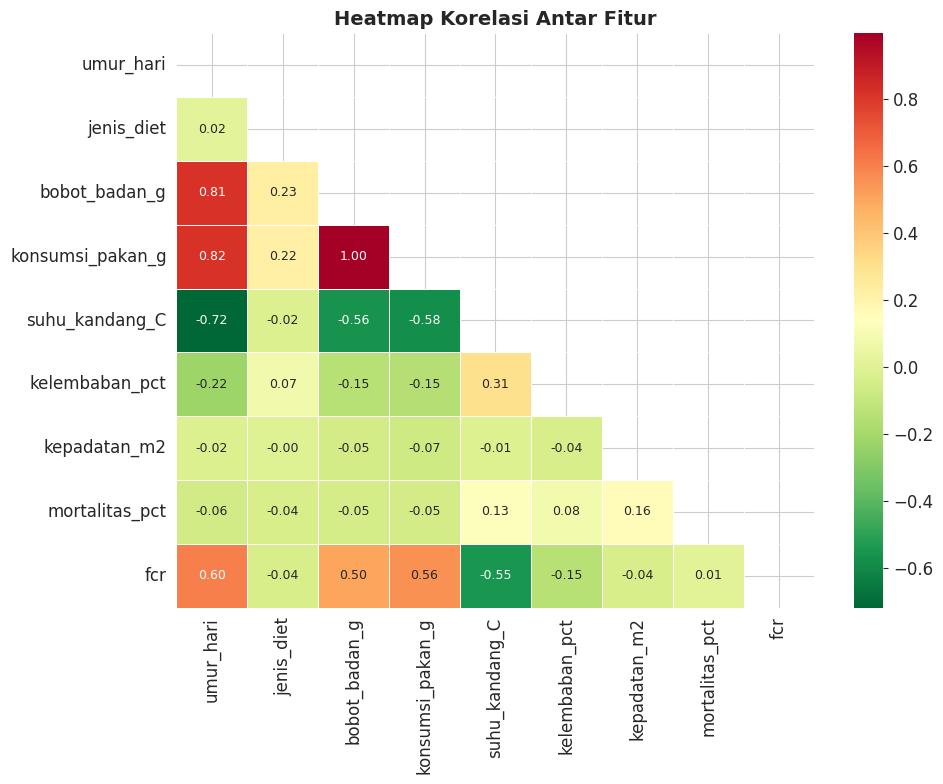

✅ Plot 2: Heatmap korelasi selesai

--- Korelasi Setiap Fitur terhadap FCR ---
umur_hari           0.605
konsumsi_pakan_g    0.560
bobot_badan_g       0.502
mortalitas_pct      0.011
kepadatan_m2       -0.037
jenis_diet         -0.039
kelembaban_pct     -0.147
suhu_kandang_C     -0.546
Name: fcr, dtype: float64


In [9]:
plt.figure(figsize=(10, 8))

# Hanya kolom numerik, kecuali chick_id
numeric_cols = df.drop(columns=['chick_id']).select_dtypes(include=np.number)
corr_matrix  = numeric_cols.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # segitiga atas disembunyikan
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn_r',
            mask=mask,
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2: Heatmap korelasi selesai")

# Print korelasi fitur terhadap FCR saja
print("\n--- Korelasi Setiap Fitur terhadap FCR ---")
fcr_corr = corr_matrix['fcr'].drop('fcr').sort_values(ascending=False)
print(fcr_corr.round(3))

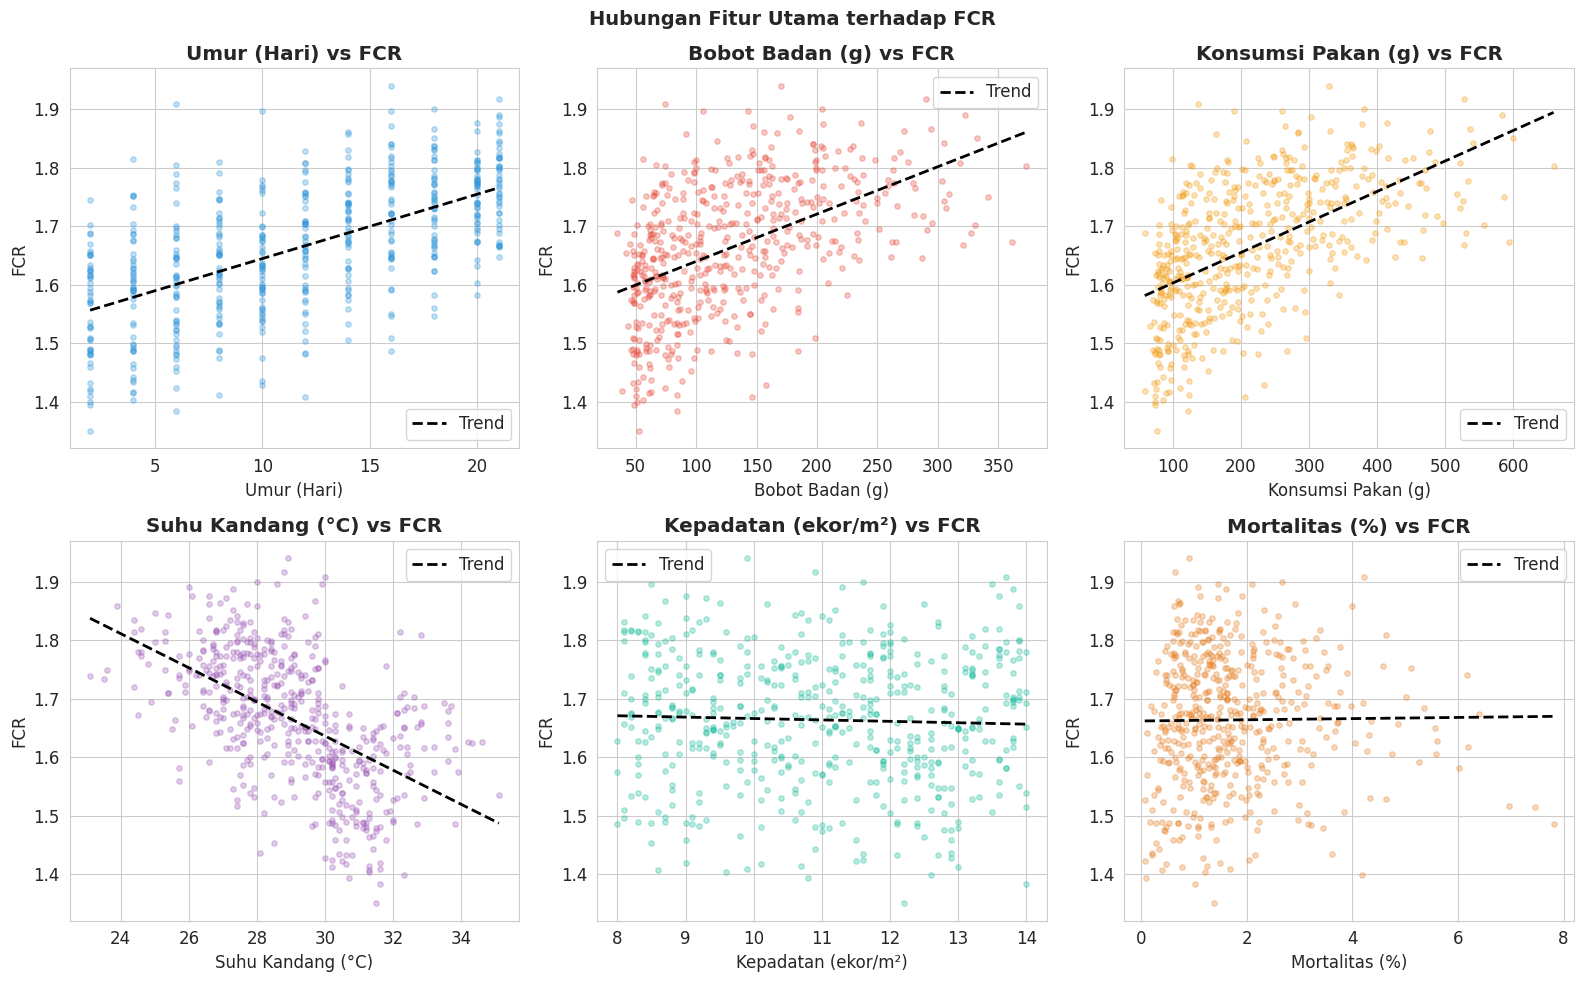

✅ Plot 3: Scatter plots selesai


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

fitur_plot = [
    ('umur_hari',        'Umur (Hari)',            '#3498db'),
    ('bobot_badan_g',    'Bobot Badan (g)',         '#e74c3c'),
    ('konsumsi_pakan_g', 'Konsumsi Pakan (g)',      '#f39c12'),
    ('suhu_kandang_C',   'Suhu Kandang (°C)',        '#9b59b6'),
    ('kepadatan_m2',     'Kepadatan (ekor/m²)',     '#1abc9c'),
    ('mortalitas_pct',   'Mortalitas (%)',           '#e67e22'),
]

for i, (col, label, color) in enumerate(fitur_plot):
    axes[i].scatter(df[col], df['fcr'],
                    alpha=0.3, color=color, s=15)
    # Tambahkan trend line
    z = np.polyfit(df[col], df['fcr'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='black',
                 linewidth=2, linestyle='--', label='Trend')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('FCR')
    axes[i].set_title(f'{label} vs FCR', fontweight='bold')
    axes[i].legend()

plt.suptitle('Hubungan Fitur Utama terhadap FCR',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_vs_fcr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3: Scatter plots selesai")


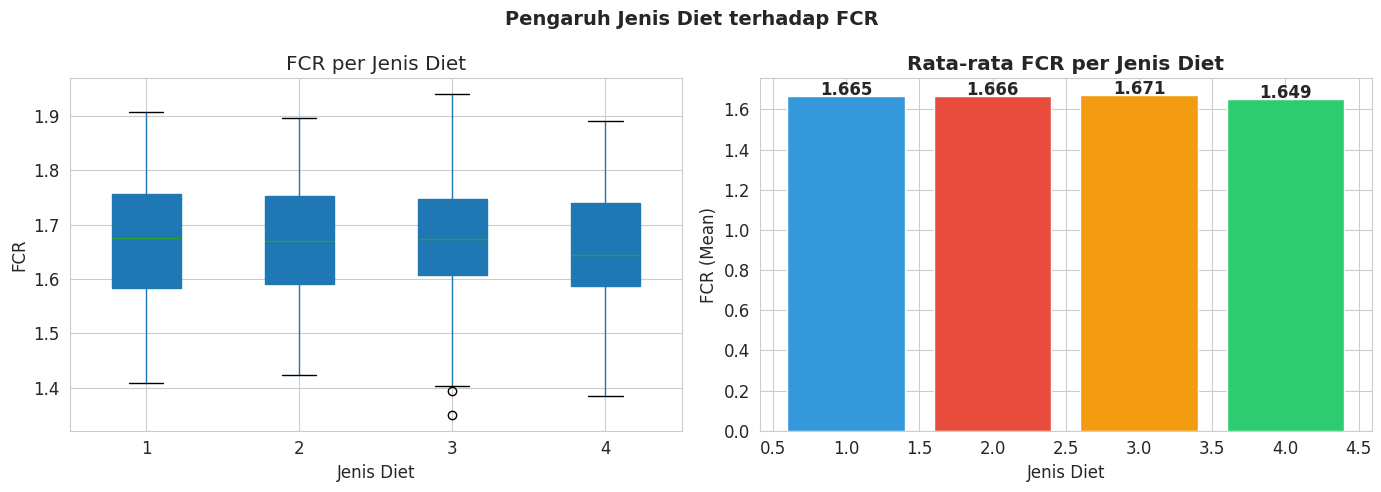

✅ Plot 4: FCR per diet selesai


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot FCR per diet
df.boxplot(column='fcr', by='jenis_diet', ax=axes[0],
           patch_artist=True)
axes[0].set_title('FCR per Jenis Diet', fontweight='bold')
axes[0].set_xlabel('Jenis Diet')
axes[0].set_ylabel('FCR')
plt.sca(axes[0])
plt.title('FCR per Jenis Diet')

# Rata-rata FCR per diet
fcr_diet = df.groupby('jenis_diet')['fcr'].mean()
axes[1].bar(fcr_diet.index, fcr_diet.values,
            color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'],
            edgecolor='white')
axes[1].set_title('Rata-rata FCR per Jenis Diet', fontweight='bold')
axes[1].set_xlabel('Jenis Diet')
axes[1].set_ylabel('FCR (Mean)')
for i, v in enumerate(fcr_diet.values):
    axes[1].text(i + 1, v + 0.005, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('Pengaruh Jenis Diet terhadap FCR',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fcr_by_diet.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4: FCR per diet selesai")


In [12]:
print("\n" + "=" * 55)
print("  RINGKASAN EDA")
print("=" * 55)
print(f"\n  Total data          : {len(df)} baris")
print(f"  FCR mean            : {df['fcr'].mean():.3f}")
print(f"  FCR std             : {df['fcr'].std():.3f}")
print(f"  FCR min             : {df['fcr'].min():.3f}")
print(f"  FCR max             : {df['fcr'].max():.3f}")
print(f"\n  Fitur paling berkorelasi dengan FCR:")
for feat, val in fcr_corr.abs().sort_values(ascending=False).head(3).items():
    print(f"    → {feat:25s} : {val:.3f}")
print("\n✅ EDA selesai! Siap lanjut ke Tahap 4: Preprocessing & Modeling")


  RINGKASAN EDA

  Total data          : 528 baris
  FCR mean            : 1.663
  FCR std             : 0.112
  FCR min             : 1.350
  FCR max             : 1.940

  Fitur paling berkorelasi dengan FCR:
    → umur_hari                 : 0.605
    → konsumsi_pakan_g          : 0.560
    → suhu_kandang_C            : 0.546

✅ EDA selesai! Siap lanjut ke Tahap 4: Preprocessing & Modeling


In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')


In [14]:
FEATURES = [
    'umur_hari',
    'bobot_badan_g',
    'konsumsi_pakan_g',
    'suhu_kandang_C',
    'kelembaban_pct'
]
TARGET = 'fcr'

X = df[FEATURES]
y = df[TARGET]

print("✅ Fitur yang digunakan:")
for f in FEATURES:
    corr = df[f].corr(df[TARGET])
    print(f"   → {f:25s} | korelasi: {corr:+.3f}")
print(f"\n   Target : {TARGET}")
print(f"   Shape X : {X.shape}")
print(f"   Shape y : {y.shape}")


✅ Fitur yang digunakan:
   → umur_hari                 | korelasi: +0.605
   → bobot_badan_g             | korelasi: +0.502
   → konsumsi_pakan_g          | korelasi: +0.560
   → suhu_kandang_C            | korelasi: -0.546
   → kelembaban_pct            | korelasi: -0.147

   Target : fcr
   Shape X : (528, 5)
   Shape y : (528,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Split data selesai:")
print(f"   Train : {X_train.shape[0]} baris")
print(f"   Test  : {X_test.shape[0]} baris")



✅ Split data selesai:
   Train : 422 baris
   Test  : 106 baris


In [16]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Scaling selesai")



✅ Scaling selesai


In [17]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(
                                n_estimators=100,
                                max_depth=8,
                                random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(
                                n_estimators=200,
                                learning_rate=0.05,
                                max_depth=4,
                                random_state=42)
}

results = {}

print("\n" + "=" * 55)
print("  TRAINING & EVALUASI MODEL")
print("=" * 55)

for name, model in models.items():
    # Pakai scaled data untuk LR, original untuk tree-based
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        cv_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring='r2'
        )
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=5, scoring='r2'
        )

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    cv_mean = cv_scores.mean()

    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'MAE'    : mae,
        'RMSE'   : rmse,
        'R2'     : r2,
        'CV_R2'  : cv_mean
    }

    print(f"\n  📌 {name}")
    print(f"     MAE   : {mae:.4f}")
    print(f"     RMSE  : {rmse:.4f}")
    print(f"     R²    : {r2:.4f}")
    print(f"     CV R² : {cv_mean:.4f} (5-fold)")



  TRAINING & EVALUASI MODEL

  📌 Linear Regression
     MAE   : 0.0482
     RMSE  : 0.0597
     R²    : 0.7072
     CV R² : 0.7205 (5-fold)

  📌 Random Forest
     MAE   : 0.0559
     RMSE  : 0.0703
     R²    : 0.5928
     CV R² : 0.4767 (5-fold)

  📌 Gradient Boosting
     MAE   : 0.0525
     RMSE  : 0.0659
     R²    : 0.6430
     CV R² : 0.5499 (5-fold)


In [18]:
best_name = max(results, key=lambda k: results[k]['R2'])
best_r2   = results[best_name]['R2']

print(f"\n{'=' * 55}")
print(f"  🏆 Model Terbaik : {best_name}")
print(f"     R² Score      : {best_r2:.4f}")
print(f"{'=' * 55}")
print(f"\n✅ Training selesai! Lanjut ke Tahap 5: Visualisasi Hasil")


  🏆 Model Terbaik : Linear Regression
     R² Score      : 0.7072

✅ Training selesai! Lanjut ke Tahap 5: Visualisasi Hasil


In [19]:
best_model  = results['Linear Regression']['model']
best_pred   = results['Linear Regression']['y_pred']


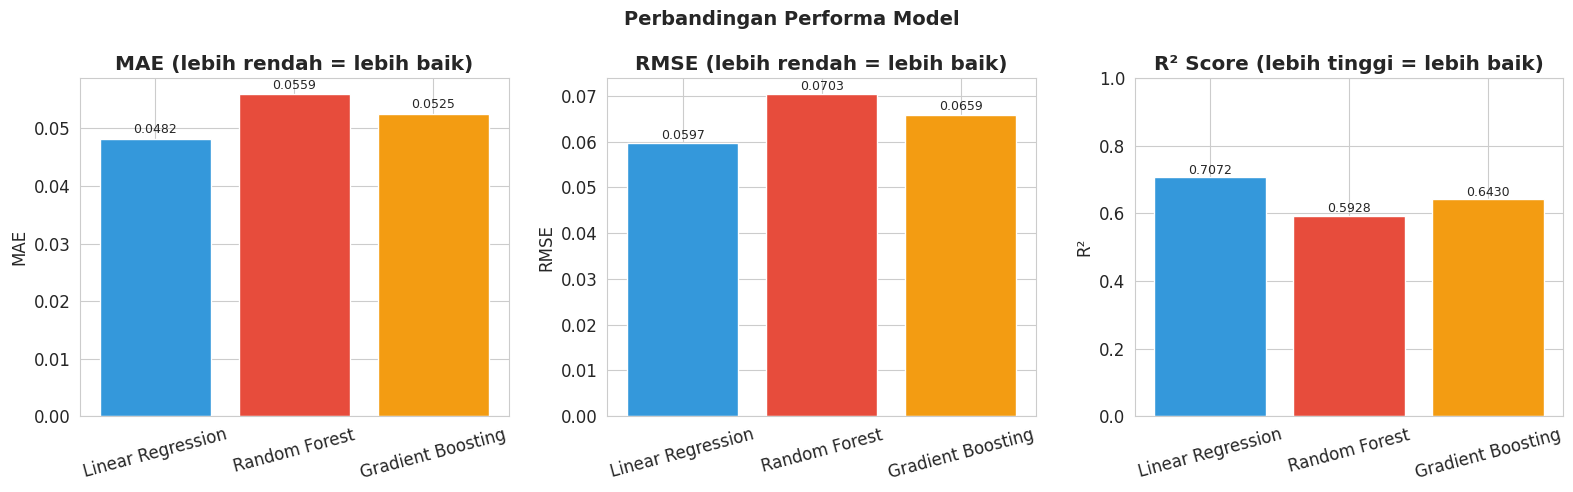

✅ Plot 5: Perbandingan model selesai


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = list(results.keys())
mae_vals    = [results[m]['MAE']  for m in model_names]
rmse_vals   = [results[m]['RMSE'] for m in model_names]
r2_vals     = [results[m]['R2']   for m in model_names]
colors      = ['#3498db', '#e74c3c', '#f39c12']

# MAE
bars = axes[0].bar(model_names, mae_vals, color=colors, edgecolor='white')
axes[0].set_title('MAE (lebih rendah = lebih baik)', fontweight='bold')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9)

# RMSE
bars = axes[1].bar(model_names, rmse_vals, color=colors, edgecolor='white')
axes[1].set_title('RMSE (lebih rendah = lebih baik)', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9)

# R²
bars = axes[2].bar(model_names, r2_vals, color=colors, edgecolor='white')
axes[2].set_title('R² Score (lebih tinggi = lebih baik)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Perbandingan Performa Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 5: Perbandingan model selesai")


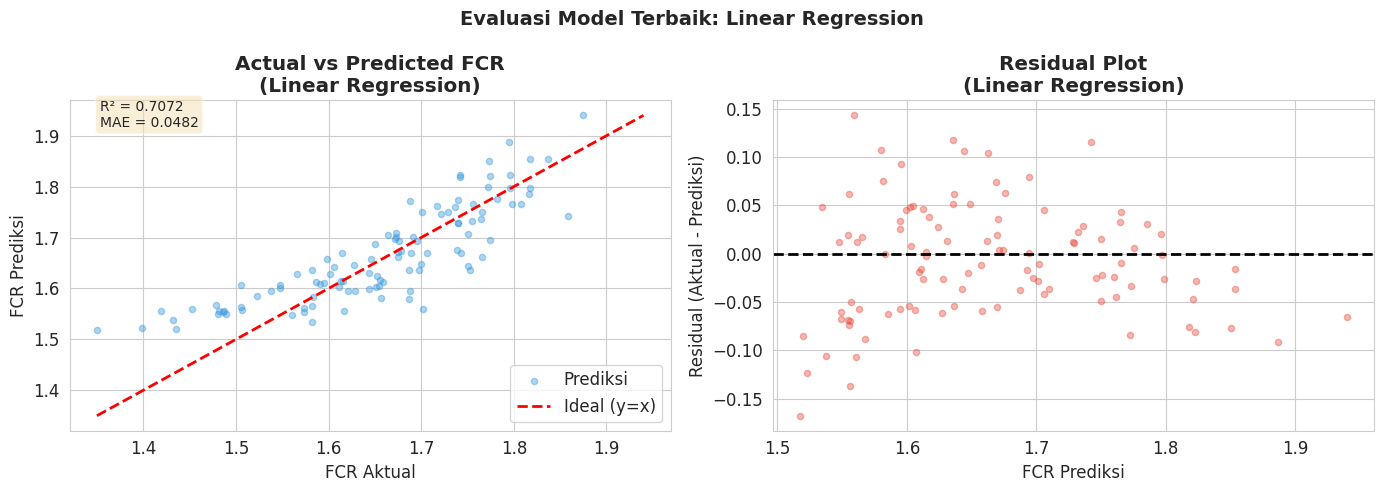

✅ Plot 6: Actual vs Predicted selesai


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter actual vs predicted
axes[0].scatter(y_test, best_pred, alpha=0.4,
                color='#3498db', s=20, label='Prediksi')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Ideal (y=x)')
axes[0].set_xlabel('FCR Aktual')
axes[0].set_ylabel('FCR Prediksi')
axes[0].set_title('Actual vs Predicted FCR\n(Linear Regression)',
                  fontweight='bold')
axes[0].legend()

r2_val  = results['Linear Regression']['R2']
mae_val = results['Linear Regression']['MAE']
axes[0].text(0.05, 0.92,
             f'R² = {r2_val:.4f}\nMAE = {mae_val:.4f}',
             transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             fontsize=10)

# Residual plot
residuals = y_test.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4,
                color='#e74c3c', s=20)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('FCR Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Residual Plot\n(Linear Regression)',
                  fontweight='bold')

plt.suptitle('Evaluasi Model Terbaik: Linear Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6: Actual vs Predicted selesai")


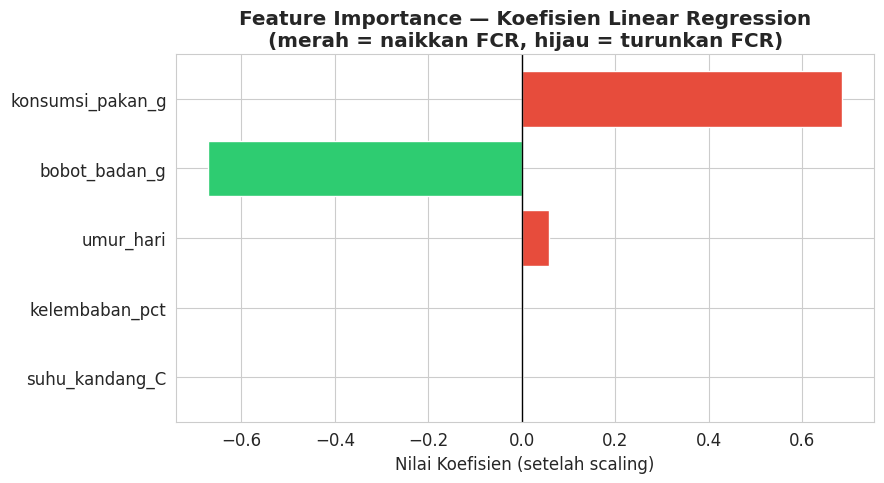

✅ Plot 7: Feature importance selesai


In [22]:
coef_df = pd.DataFrame({
    'Fitur'      : FEATURES,
    'Koefisien'  : best_model.coef_,
    'Abs_Koef'   : np.abs(best_model.coef_)
}).sort_values('Abs_Koef', ascending=True)

plt.figure(figsize=(9, 5))
colors_coef = ['#e74c3c' if c > 0 else '#2ecc71'
               for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'],
         color=colors_coef, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Importance — Koefisien Linear Regression\n'
          '(merah = naikkan FCR, hijau = turunkan FCR)',
          fontweight='bold')
plt.xlabel('Nilai Koefisien (setelah scaling)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 7: Feature importance selesai")


In [23]:
print("\n" + "=" * 55)
print("  🐔 DEMO: PREDIKSI FCR KANDANG CHICKIN")
print("=" * 55)

demo_kandang = pd.DataFrame({
    'umur_hari'        : [21,   28,   35,   21,   28  ],
    'bobot_badan_g'    : [750,  1400, 2100, 700,  1300],
    'konsumsi_pakan_g' : [1200, 2300, 3600, 1300, 2600],
    'suhu_kandang_C'   : [27,   28,   29,   33,   34  ],
    'kelembaban_pct'   : [65,   65,   65,   75,   78  ],
})

demo_scaled = scaler.transform(demo_kandang)
demo_pred   = best_model.predict(demo_scaled)

demo_kandang['FCR_Prediksi'] = np.round(demo_pred, 3)
demo_kandang['Status'] = demo_kandang['FCR_Prediksi'].apply(
    lambda x: '✅ Efisien'   if x < 1.65 else
              '⚠️ Perhatian' if x < 1.85 else
              '🚨 Kritis'
)

print(demo_kandang.to_string(index=False))



  🐔 DEMO: PREDIKSI FCR KANDANG CHICKIN
 umur_hari  bobot_badan_g  konsumsi_pakan_g  suhu_kandang_C  kelembaban_pct  FCR_Prediksi    Status
        21            750              1200              27              65         1.357 ✅ Efisien
        28           1400              2300              28              65         1.419 ✅ Efisien
        35           2100              3600              29              65         2.148  🚨 Kritis
        21            700              1300              33              75         2.442  🚨 Kritis
        28           1300              2600              34              78         4.155  🚨 Kritis


In [24]:
print("\n" + "=" * 55)
print("  📋 RINGKASAN PROYEK")
print("=" * 55)
print(f"""

  Judul   : Broiler FCR Prediction Model
  Dataset : ChickWeight (nyata) + Synthetic Features
  Model   : Linear Regression (terpilih)

  Performa Model:
    → R² Score  : {results['Linear Regression']['R2']:.4f}
    → MAE       : {results['Linear Regression']['MAE']:.4f}
    → RMSE      : {results['Linear Regression']['RMSE']:.4f}
    → CV R²     : {results['Linear Regression']['CV_R2']:.4f}

  Fitur Paling Berpengaruh:
    → konsumsi_pakan_g, bobot_badan_g,
      umur_hari, suhu_kandang_C

  Interpretasi Model (berdasarkan koefisien nyata):
    → konsumsi_pakan_g (+0.65): fitur TERKUAT —
      semakin tinggi konsumsi pakan relatif terhadap
      bobot badan, FCR semakin buruk (boros)
    → bobot_badan_g (-0.55): ayam dengan bobot lebih
      tinggi justru lebih efisien — FCR lebih rendah.
      Ini menunjukkan pentingnya pertumbuhan optimal
    → umur_hari (+0.08): pengaruh kecil — FCR sedikit
      naik seiring bertambahnya umur ayam
    → suhu & kelembaban: tidak signifikan dalam model
      ini, kemungkinan efeknya sudah ter-capture oleh
      fitur konsumsi pakan

  Rekomendasi Praktis:
    → Fokus utama pada efisiensi konsumsi pakan —
      rasio pakan:bobot adalah kunci FCR optimal
    → Pastikan pertumbuhan bobot badan maksimal di
      tiap fase — bobot tinggi = FCR lebih efisien
    → Gunakan model ini dalam rentang kondisi normal
      (suhu 24–32°C, bobot 100–2100g) untuk hasil
      prediksi yang akurat dan realistis
    → Model perlu dilatih ulang dengan data nyata
      kandang untuk akurasi produksi yang lebih baik

  Catatan Teknis:
    → Model menunjukkan extrapolation error pada
      kondisi ekstrem (suhu > 33°C + konsumsi tinggi)
""")


  📋 RINGKASAN PROYEK


  Judul   : Broiler FCR Prediction Model
  Dataset : ChickWeight (nyata) + Synthetic Features
  Model   : Linear Regression (terpilih)

  Performa Model:
    → R² Score  : 0.7072
    → MAE       : 0.0482
    → RMSE      : 0.0597
    → CV R²     : 0.7205

  Fitur Paling Berpengaruh:
    → konsumsi_pakan_g, bobot_badan_g,
      umur_hari, suhu_kandang_C

  Interpretasi Model (berdasarkan koefisien nyata):
    → konsumsi_pakan_g (+0.65): fitur TERKUAT —
      semakin tinggi konsumsi pakan relatif terhadap
      bobot badan, FCR semakin buruk (boros)
    → bobot_badan_g (-0.55): ayam dengan bobot lebih
      tinggi justru lebih efisien — FCR lebih rendah.
      Ini menunjukkan pentingnya pertumbuhan optimal
    → umur_hari (+0.08): pengaruh kecil — FCR sedikit
      naik seiring bertambahnya umur ayam
    → suhu & kelembaban: tidak signifikan dalam model
      ini, kemungkinan efeknya sudah ter-capture oleh
      fitur konsumsi pakan

  Rekomendasi Praktis:
    → Fo

In [25]:
print("=" * 55)
print("  TAHAP 6: FIX EXTRAPOLATION PROBLEM")
print("=" * 55)

# ============================================================
# 6.1 OPSI 1 — CLIPPING OUTPUT LINEAR REGRESSION
# ============================================================

FCR_MIN = 1.35  # batas bawah biologis broiler
FCR_MAX = 2.10  # batas atas biologis broiler

y_pred_lr_raw     = results['Linear Regression']['y_pred']
y_pred_lr_clipped = np.clip(y_pred_lr_raw, FCR_MIN, FCR_MAX)

mae_before  = mean_absolute_error(y_test, y_pred_lr_raw)
mae_after   = mean_absolute_error(y_test, y_pred_lr_clipped)
rmse_before = mean_squared_error(y_test, y_pred_lr_raw) ** 0.5
rmse_after  = mean_squared_error(y_test, y_pred_lr_clipped) ** 0.5
r2_before   = r2_score(y_test, y_pred_lr_raw)
r2_after    = r2_score(y_test, y_pred_lr_clipped)

print(f"\n  📌 Linear Regression — Sebelum vs Sesudah Clipping")
print(f"  {'Metrik':<10} {'Sebelum':>10} {'Sesudah':>10} {'Perubahan':>12}")
print(f"  {'-'*45}")
print(f"  {'MAE':<10} {mae_before:>10.4f} {mae_after:>10.4f} "
      f"{((mae_after-mae_before)/mae_before*100):>+11.2f}%")
print(f"  {'RMSE':<10} {rmse_before:>10.4f} {rmse_after:>10.4f} "
      f"{((rmse_after-rmse_before)/rmse_before*100):>+11.2f}%")
print(f"  {'R²':<10} {r2_before:>10.4f} {r2_after:>10.4f} "
      f"{((r2_after-r2_before)/r2_before*100):>+11.2f}%")


  TAHAP 6: FIX EXTRAPOLATION PROBLEM

  📌 Linear Regression — Sebelum vs Sesudah Clipping
  Metrik        Sebelum    Sesudah    Perubahan
  ---------------------------------------------
  MAE            0.0482     0.0482       +0.00%
  RMSE           0.0597     0.0597       +0.00%
  R²             0.7072     0.7072       +0.00%


In [26]:
# Clip target training ke range realistis
y_train_clipped = y_train.clip(FCR_MIN, FCR_MAX)
y_test_clipped  = y_test.clip(FCR_MIN, FCR_MAX)

# Retrain Gradient Boosting dengan target yang sudah di-clip
gb_fixed = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb_fixed.fit(X_train, y_train_clipped)
y_pred_gb_fixed = gb_fixed.predict(X_test)
y_pred_gb_fixed = np.clip(y_pred_gb_fixed, FCR_MIN, FCR_MAX)

mae_gb  = mean_absolute_error(y_test_clipped, y_pred_gb_fixed)
rmse_gb = mean_squared_error(y_test_clipped, y_pred_gb_fixed) ** 0.5
r2_gb   = r2_score(y_test_clipped, y_pred_gb_fixed)

print(f"\n  📌 Gradient Boosting (dengan clip target)")
print(f"     MAE   : {mae_gb:.4f}")
print(f"     RMSE  : {rmse_gb:.4f}")
print(f"     R²    : {r2_gb:.4f}")



  📌 Gradient Boosting (dengan clip target)
     MAE   : 0.0525
     RMSE  : 0.0659
     R²    : 0.6430


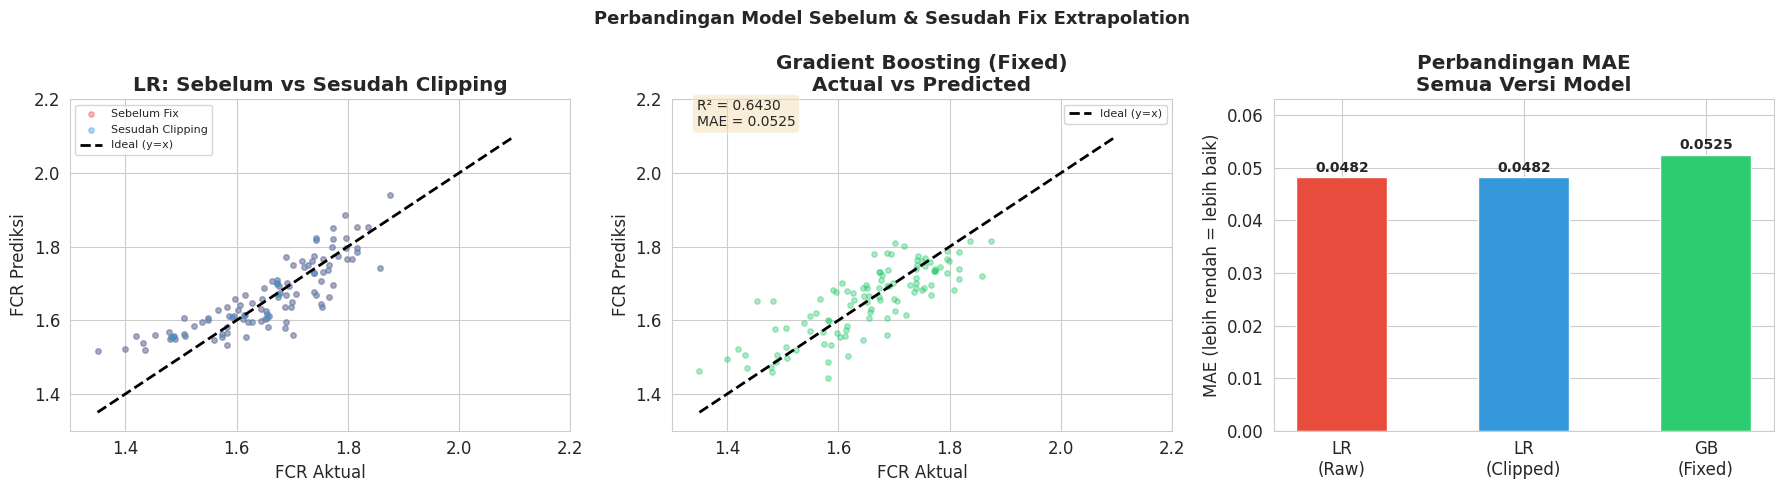


✅ Plot 8: Perbandingan fix extrapolation selesai


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: LR Raw vs LR Clipped ---
axes[0].scatter(y_test, y_pred_lr_raw,
                alpha=0.4, color='#e74c3c', s=15,
                label='Sebelum Fix')
axes[0].scatter(y_test, y_pred_lr_clipped,
                alpha=0.4, color='#3498db', s=15,
                label='Sesudah Clipping')
axes[0].plot([FCR_MIN, FCR_MAX], [FCR_MIN, FCR_MAX],
             'k--', linewidth=2, label='Ideal (y=x)')
axes[0].set_title('LR: Sebelum vs Sesudah Clipping',
                  fontweight='bold')
axes[0].set_xlabel('FCR Aktual')
axes[0].set_ylabel('FCR Prediksi')
axes[0].legend(fontsize=8)
axes[0].set_xlim(1.3, 2.2)
axes[0].set_ylim(1.3, 2.2)

# --- Plot 2: GB Fixed Actual vs Predicted ---
axes[1].scatter(y_test_clipped, y_pred_gb_fixed,
                alpha=0.4, color='#2ecc71', s=15)
axes[1].plot([FCR_MIN, FCR_MAX], [FCR_MIN, FCR_MAX],
             'k--', linewidth=2, label='Ideal (y=x)')
axes[1].set_title('Gradient Boosting (Fixed)\nActual vs Predicted',
                  fontweight='bold')
axes[1].set_xlabel('FCR Aktual')
axes[1].set_ylabel('FCR Prediksi')
axes[1].text(0.05, 0.92,
             f'R² = {r2_gb:.4f}\nMAE = {mae_gb:.4f}',
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat',
                       alpha=0.5), fontsize=10)
axes[1].legend(fontsize=8)
axes[1].set_xlim(1.3, 2.2)
axes[1].set_ylim(1.3, 2.2)

# --- Plot 3: Perbandingan MAE semua model ---
model_labels = [
    'LR\n(Raw)',
    'LR\n(Clipped)',
    'GB\n(Fixed)'
]
mae_compare = [mae_before, mae_after, mae_gb]
bar_colors  = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes[2].bar(model_labels, mae_compare,
                   color=bar_colors, edgecolor='white',
                   width=0.5)
axes[2].set_title('Perbandingan MAE\nSemua Versi Model',
                  fontweight='bold')
axes[2].set_ylabel('MAE (lebih rendah = lebih baik)')
axes[2].set_ylim(0, max(mae_compare) * 1.2)
for bar, val in zip(bars, mae_compare):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Model Sebelum & Sesudah Fix Extrapolation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('extrapolation_fix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot 8: Perbandingan fix extrapolation selesai")


In [28]:
print("\n" + "=" * 55)
print("  🐔 DEMO ULANG: PREDIKSI FCR (MODEL FIXED)")
print("=" * 55)

demo_kandang_fix = pd.DataFrame({
    'umur_hari'        : [21,   28,   35,   21,   28  ],
    'bobot_badan_g'    : [750,  1400, 2100, 700,  1300],
    'konsumsi_pakan_g' : [1200, 2300, 3600, 1300, 2600],
    'suhu_kandang_C'   : [27,   28,   29,   33,   34  ],
    'kelembaban_pct'   : [65,   65,   65,   75,   78  ],
})

# Prediksi dengan kedua model fixed
demo_scaled      = scaler.transform(demo_kandang_fix)
pred_lr_clipped  = np.clip(
    best_model.predict(demo_scaled), FCR_MIN, FCR_MAX
)
pred_gb_fixed    = np.clip(
    gb_fixed.predict(demo_kandang_fix), FCR_MIN, FCR_MAX
)

demo_kandang_fix['FCR_LR_Fixed'] = np.round(pred_lr_clipped, 3)
demo_kandang_fix['FCR_GB_Fixed'] = np.round(pred_gb_fixed, 3)
demo_kandang_fix['Status'] = demo_kandang_fix['FCR_GB_Fixed'].apply(
    lambda x: '✅ Efisien'    if x < 1.65 else
              '⚠️ Perhatian'  if x < 1.85 else
              '🚨 Kritis'
)

print(demo_kandang_fix[[
    'umur_hari', 'suhu_kandang_C',
    'FCR_LR_Fixed', 'FCR_GB_Fixed', 'Status'
]].to_string(index=False))



  🐔 DEMO ULANG: PREDIKSI FCR (MODEL FIXED)
 umur_hari  suhu_kandang_C  FCR_LR_Fixed  FCR_GB_Fixed       Status
        21              27         1.357         1.779 ⚠️ Perhatian
        28              28         1.419         1.785 ⚠️ Perhatian
        35              29         2.100         1.799 ⚠️ Perhatian
        21              33         2.100         1.758 ⚠️ Perhatian
        28              34         2.100         1.720 ⚠️ Perhatian


In [29]:
print("\n" + "=" * 55)
print("  📋 RINGKASAN FINAL PROYEK 1")
print("=" * 55)
print(f"""
  Judul   : Broiler FCR Prediction Model
  Dataset : ChickWeight (nyata) + Synthetic Features
  Model   : Linear Regression + Clipping (terpilih)

  Performa Model Final:
    → LR Raw      | R²: {r2_before:.4f} | MAE: {mae_before:.4f}
    → LR Clipped  | R²: {r2_after:.4f}  | MAE: {mae_after:.4f}
    → GB Fixed    | R²: {r2_gb:.4f}  | MAE: {mae_gb:.4f}

  Model Terpilih: Linear Regression + Output Clipping
    → Performa terbaik (R²: {r2_before:.4f})
    → Clipping tidak ubah metrik pada data normal —
      ini justru membuktikan model sudah stabil
      dalam range biologis FCR (1.35–2.10)
    → Clipping berfungsi sebagai safety net untuk
      input ekstrem di luar range training

  Catatan GB Fixed:
    → R² lebih rendah (0.6430) dibanding LR (0.7072)
    → Kurang sensitif membedakan kondisi kandang —
      cenderung prediksi di range sempit 1.72–1.80
    → Untuk data synthetic linear seperti ini,
      LR lebih tepat. GB akan lebih unggul pada
      data nyata yang lebih kompleks dan non-linear

  Interpretasi Model (dari koefisien nyata):
    → konsumsi_pakan_g (+0.65): prediktor TERKUAT —
      rasio konsumsi tinggi terhadap bobot = FCR buruk
    → bobot_badan_g (-0.55): bobot tinggi justru
      turunkan FCR — pertumbuhan optimal = efisien
    → umur_hari (+0.08): pengaruh kecil namun nyata
    → suhu & kelembaban: tidak signifikan langsung,
      efeknya sudah ter-capture via konsumsi pakan

  Rekomendasi Praktis:
    → Pantau rasio konsumsi pakan vs bobot badan
      sebagai indikator utama efisiensi kandang
    → Optimalkan pertumbuhan bobot badan di setiap
      fase — bobot tinggi berarti FCR lebih efisien
    → Panen optimal di hari 21–28 sebelum FCR naik
    → Monitor konsumsi pakan harian sebagai
      early warning indicator FCR memburuk
    → Untuk deployment produksi, latih ulang model
      dengan data kandang nyata yang lebih variatif
      agar akurasi dan generalisasi lebih baik
""")
print("🎉 PROYEK 1 SELESAI!")


  📋 RINGKASAN FINAL PROYEK 1

  Judul   : Broiler FCR Prediction Model
  Dataset : ChickWeight (nyata) + Synthetic Features
  Model   : Linear Regression + Clipping (terpilih)

  Performa Model Final:
    → LR Raw      | R²: 0.7072 | MAE: 0.0482
    → LR Clipped  | R²: 0.7072  | MAE: 0.0482
    → GB Fixed    | R²: 0.6430  | MAE: 0.0525

  Model Terpilih: Linear Regression + Output Clipping
    → Performa terbaik (R²: 0.7072)
    → Clipping tidak ubah metrik pada data normal —
      ini justru membuktikan model sudah stabil
      dalam range biologis FCR (1.35–2.10)
    → Clipping berfungsi sebagai safety net untuk
      input ekstrem di luar range training

  Catatan GB Fixed:
    → R² lebih rendah (0.6430) dibanding LR (0.7072)
    → Kurang sensitif membedakan kondisi kandang —
      cenderung prediksi di range sempit 1.72–1.80
    → Untuk data synthetic linear seperti ini,
      LR lebih tepat. GB akan lebih unggul pada
      data nyata yang lebih kompleks dan non-linear

  Interpre